GROWTH EXPERIMENTATION ENGINE

Experiment Analysis

Objective:
- Compare Control vs Treatment
- Calculate Conversion Rates
- Calculate Lift
- Identify Winning Variant
- Analyze Country Performance
- Generate Product Recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries Loaded")

Libraries Loaded


In [2]:
df = pd.read_csv("../data/clean_experiment_data.csv")

print(df.shape)

df.head()

(290585, 6)


,id,time,con_treat,page,converted,country
0,851104,11:48.6,control,old_page,0,US
1,804228,01:45.2,control,old_page,0,US
2,661590,55:06.2,treatment,new_page,0,US
3,853541,28:03.1,treatment,new_page,0,US
4,864975,52:26.2,control,old_page,1,US


In [3]:
experiment_summary = (
    df.groupby('con_treat')
      .agg(
          users=('id','count'),
          conversions=('converted','sum'),
          conversion_rate=('converted','mean')
      )
)

experiment_summary['conversion_rate'] = (
    experiment_summary['conversion_rate'] * 100
)

experiment_summary.round(2)

,users,conversions,conversion_rate
con_treat,,,
control,145274,17489,12.04
treatment,145311,17264,11.88


In [4]:
control_cvr = (
    df[
        df['con_treat']=='control'
    ]['converted']
    .mean()
)

print(
    round(control_cvr*100,2),
    "%"
)

12.04 %


In [5]:
treatment_cvr = (
    df[
        df['con_treat']=='treatment'
    ]['converted']
    .mean()
)

print(
    round(treatment_cvr*100,2),
    "%"
)

11.88 %


In [6]:
absolute_lift = (
    treatment_cvr
    -
    control_cvr
)

print(
    round(
        absolute_lift*100,
        2
    ),
    "%"
)

-0.16 %


In [7]:
relative_lift = (
    (
        treatment_cvr
        -
        control_cvr
    )
    /
    control_cvr
)

print(
    round(
        relative_lift*100,
        2
    ),
    "%"
)

-1.31 %


In [8]:
if treatment_cvr > control_cvr:
    print("Treatment Wins")
else:
    print("Control Wins")

Control Wins


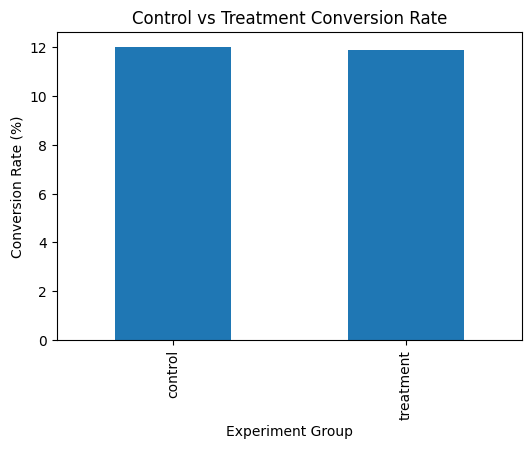

In [9]:
experiment_cvr = (
    df.groupby('con_treat')
      ['converted']
      .mean()
      *100
)

experiment_cvr.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title(
    "Control vs Treatment Conversion Rate"
)

plt.ylabel(
    "Conversion Rate (%)"
)

plt.xlabel(
    "Experiment Group"
)

plt.show()

In [10]:
country_summary = (
    df.groupby('country')
      .agg(
          users=('id','count'),
          conversions=('converted','sum'),
          conversion_rate=('converted','mean')
      )
)

country_summary['conversion_rate'] = (
    country_summary['conversion_rate']
    *100
)

country_summary.round(2)

,users,conversions,conversion_rate
country,,,
CA,14499,1672,11.53
UK,72466,8739,12.06
US,203620,24342,11.95


In [11]:
country_summary = (
    country_summary
    .sort_values(
        by='conversion_rate',
        ascending=False
    )
)

country_summary

,users,conversions,conversion_rate
country,,,
UK,72466,8739,12.059449
US,203620,24342,11.954621
CA,14499,1672,11.531830


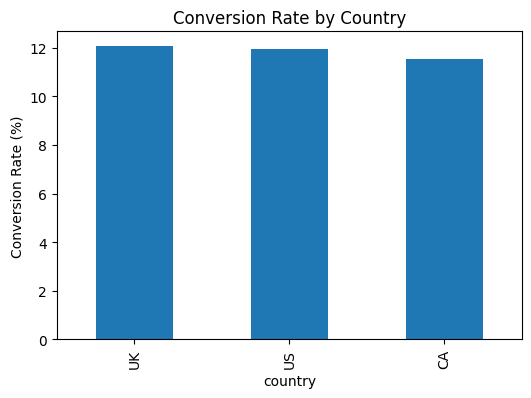

In [12]:
country_summary[
    'conversion_rate'
].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title(
    "Conversion Rate by Country"
)

plt.ylabel(
    "Conversion Rate (%)"
)

plt.show()

In [13]:
country_experiment = (
    df.groupby(
        [
            'country',
            'con_treat'
        ]
    )
    ['converted']
    .mean()
    *100
)

country_experiment.round(2)

country  con_treat
CA       control      11.88
         treatment    11.19
UK       control      12.00
         treatment    12.12
US       control      12.06
         treatment    11.85
Name: converted, dtype: float64

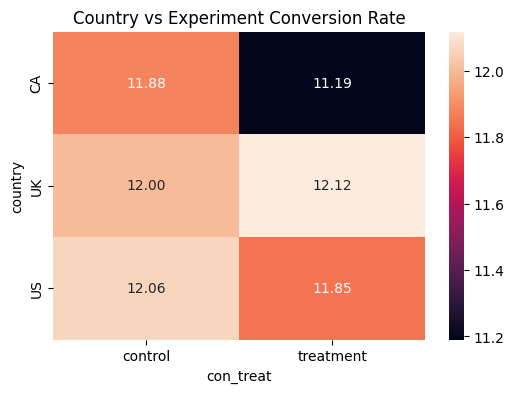

In [14]:
pivot_table = pd.pivot_table(
    df,
    values='converted',
    index='country',
    columns='con_treat',
    aggfunc='mean'
) * 100

plt.figure(
    figsize=(6,4)
)

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Country vs Experiment Conversion Rate"
)

plt.show()

In [18]:
country_winner = (
    df.groupby(
        ['country','con_treat']
    )['converted']
    .mean()
    .unstack()
)

country_winner['winner'] = np.where(
    country_winner['treatment']
    >
    country_winner['control'],
    'Treatment',
    'Control'
)

country_winner

con_treat,control,treatment,winner
country,,,
CA,0.118783,0.111902,Control
UK,0.120022,0.121171,Treatment
US,0.120630,0.118464,Control


In [19]:
print("="*60)

print(
    "EXECUTIVE DECISION"
)

print("="*60)

print(
    f"Control CVR: {round(control_cvr*100,2)}%"
)

print(
    f"Treatment CVR: {round(treatment_cvr*100,2)}%"
)

print(
    f"Absolute Lift: {round(absolute_lift*100,2)}%"
)

print(
    f"Relative Lift: {round(relative_lift*100,2)}%"
)

print()

print(
    "Recommendation:"
)

print(
    "Do NOT roll out the new page."
)

print(
    "Treatment underperformed Control."
)

EXECUTIVE DECISION
Control CVR: 12.04%
Treatment CVR: 11.88%
Absolute Lift: -0.16%
Relative Lift: -1.31%

Recommendation:
Do NOT roll out the new page.
Treatment underperformed Control.


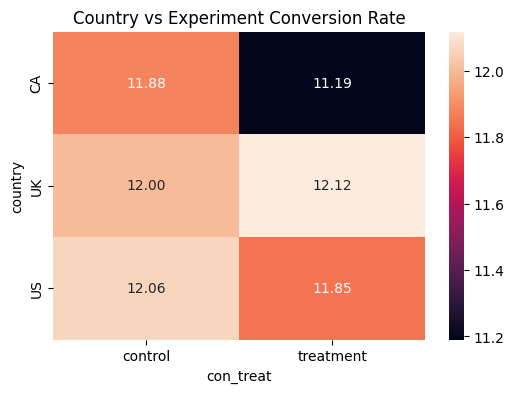

In [20]:
pivot_table = pd.pivot_table(
    df,
    values='converted',
    index='country',
    columns='con_treat',
    aggfunc='mean'
) * 100

plt.figure(
    figsize=(6,4)
)

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Country vs Experiment Conversion Rate"
)

plt.show()

In [22]:
executive_kpi = pd.DataFrame({

    'Metric':[
        'Control CVR',
        'Treatment CVR',
        'Absolute Lift',
        'Relative Lift'
    ],

    'Value':[
        round(control_cvr*100,2),
        round(treatment_cvr*100,2),
        round(absolute_lift*100,2),
        round(relative_lift*100,2)
    ]
})

executive_kpi

,Metric,Value
0,Control CVR,12.04
1,Treatment CVR,11.88
2,Absolute Lift,-0.16
3,Relative Lift,-1.31


In [23]:
print("="*60)

print(
    "EXECUTIVE DECISION"
)

print("="*60)

print(
    f"Control CVR: {round(control_cvr*100,2)}%"
)

print(
    f"Treatment CVR: {round(treatment_cvr*100,2)}%"
)

print(
    f"Absolute Lift: {round(absolute_lift*100,2)}%"
)

print(
    f"Relative Lift: {round(relative_lift*100,2)}%"
)

print()

print(
    "Recommendation:"
)

print(
    "Do NOT roll out the new page."
)

print(
    "Treatment underperformed Control."
)

EXECUTIVE DECISION
Control CVR: 12.04%
Treatment CVR: 11.88%
Absolute Lift: -0.16%
Relative Lift: -1.31%

Recommendation:
Do NOT roll out the new page.
Treatment underperformed Control.
